In [1]:
import csv
import numpy as np
import glob
import json
import json
import os
import docopt
import beep
import os
import requests
import glob
import notebook

from matplotlib import pyplot as plt

In [2]:
slist = []
dir_rawdata = '/Users/siqianli/Desktop/221206_rawdata/'
dir_set = 'A43'
file_head = '43A'
string =''
files = glob.glob(dir_rawdata+dir_set+"/*") 
for file in files:
    #print(file)
    if '101cyc.csv' not in file:
        #print(file.rfind(file_head)) # find position of 43A
        slist.append(file[file.rfind(file_head):])
print(slist)
slist101 = [''] * len(slist)
files = glob.glob(dir_rawdata+dir_set+"/*") 
for file in files:
    if '101cyc.csv' in file:
        #print(file)
        #print(file.find('101cyc')-1)
        
        
        #print(file[file.rfind(file_head):file.find('101cyc')-1])
        print([s for s in slist if file[file.rfind(file_head):file.find('101cyc')-1] in s][0])
        
        
        #print([s for s in slist if file[file.rfind(file_head):file.find('101cyc')-1] in s][0])
        slist101[slist.index([s for s in slist if file[file.rfind(file_head):file.find('101cyc')-1] in s][0])] = file[file.rfind(file_head):]
        #print(slist101)
for i in range(len(slist)):
    print(slist[i],"  ",slist101[i])
    
    
print(len(slist))
print(slist101)

['43A-161.csv', '43A-163.csv', '43A-39.csv', '43A-162.csv', '43A-38.csv', '43A-39-101cycle.csv', '43A-166.csv', '43A-167.csv', '43A-165.csv', '43A-164.csv', '43A-170.csv', '43A-71.csv', '43A-65.csv', '43A-103.csv', '43A-102.csv', '43A-58.csv', '43A-70.csv', '43A-66.csv', '43A-72.csv', '43A-100.csv', '43A-99.csv', '43A-98.csv', '43A-101.csv', '43A-73.csv', '43A-67.csv', '43A-105.csv', '43A-76.csv', '43A-62.csv', '43A-104.csv', '43A-48.csv', '43A-106.csv', '43A-74.csv', '43A-61.csv', '43A-75.csv', '43A-49.csv', '43A-50.csv', '43A-44.csv', '43A-136.csv', '43A-122.csv', '43A-93.csv', '43A-123.csv', '43A-137.csv', '43A-45.csv', '43A-51.csv', '43A-47.csv', '43A-121.csv', '43A-135.csv', '43A-134.csv', '43A-120.csv', '43A-52.csv', '43A-46.csv', '43A-124.csv', '43A-42.csv', '43A-95.csv', '43A-94.csv', '43A-57.csv', '43A-119.csv', '43A-43.csv', '43A-69.csv', '43A-41.csv', '43A-96.csv', '43A-97.csv', '43A-40.csv', '43A-68.csv', '43A-169.csv', '43A-33.csv', '43A-168.csv', '43A-32.csv', '43A-31.csv

In [178]:
data_columns = ['test_time','voltage','current','','charge_capacity','','charge_energy','','','','','mode','','']
idata_columns = ['1','7','6','','9','','11','','','','','','','']
print(len(data_columns))
print(type(data_columns))
print(len(idata_columns))

14
<class 'list'>
14


In [179]:
factor_row = [1,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.02,0.02,0.0,0.0,0.0,0.0,0.0]
print(type(factor_row))
print(len(factor_row))

<class 'list'>
15


In [180]:
mkdir ./dA43

In [181]:
for index0 in range(len(slist)):
    rawdata0 = []
    # データが格納されているディレクトリ
#    csv_file = open('../../Downloads/220818_rawdata/A43/'+slist[index0],mode='r',encoding='CP932', newline='')
    csv_file = open(dir_rawdata+dir_set+'/'+slist[index0],mode='r',encoding='CP932', newline='')
    f = csv.reader(csv_file)
    icount = 0
    for row in f:
#    print(len(row))
        if len(row) == 14:
            icount +=1
            if 'サイクル' in row:
                icycle = row.index('サイクル')
                istep = row.index('ステップ')
                imode = row.index('モード')
            if icount > 3:
            #print(row)
                rawdata0.append(row)
    if slist101[index0] != '':
    # データが格納されているディレクトリ
        csv_file = open(dir_rawdata+dir_set+'/'+slist101[index0],mode='r',encoding='CP932', newline='')
        f = csv.reader(csv_file)
        icount = 0
        for row in f:
#    print(len(row))
            if len(row) == 14:
                icount +=1
                if 'サイクル' in row:
                    icycle = row.index('サイクル')
                    istep = row.index('ステップ')
                    imode = row.index('モード')
                if icount > 3:
                    tmp = int(row[icycle])+101 # cycle_stepの位置が違う
                    row[icycle] = str(tmp)
            #print(row)
                    rawdata0.append(row)
#
    index_cycle = 0
    icount = 0
    icount0 = 0
    rawdata_discharge = []
    for i in range(len(rawdata0)):
        data_row = [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
        if str(rawdata0[i][imode]) == 'Discharge':
            if index_cycle < int(rawdata0[i][icycle]):
                index_cycle = int(rawdata0[i][icycle])
                icount += 1
            for j in range(len(idata_columns)):
                if idata_columns[j] != '':
                    data_row[int(idata_columns[j])] = float(rawdata0[i][j])
            data_row[0] = icount0
            data_row[4] = float(rawdata0[i][istep])
            data_row[5] = float(icount)#float(rawdata0[i][icycle])
            rawdata_discharge.append(data_row)
            icount0 += 1
#        print( int(rawdata0[i][13]), "  ", icount)
    print(icount)
#
    f = open('./data'+dir_set+'/2022-09-27_'+slist[index0][:slist[index0].find('.csv')]+'_0C_CH01.csv',mode='w',encoding="ISO-8859-1")
    print('Data_Point,Test_Time,DateTime,Step_Time,Step_Index,Cycle_Index,Current,Voltage,Charge_Capacity,Discharge_Capacity,Charge_Energy,Discharge_Energy,dV/dt,Internal_Resistance,Temperature',file = f)
    for i in range(len(rawdata_discharge)):
        stmp = ''
        for j in range(14):
            stmp += str(rawdata_discharge[i][j]*factor_row[j]) + ','
        stmp += '30.0'
        print(stmp,file=f)
    f.close()


200
200
200
200
200
200
188
200
200
200
200
187
189
100
140
200
195
100
100
200
200
200
168
143
200
200
200
200
148
144
150
168
124
178


In [8]:
mkdir battery

In [4]:
pwdir = '/Users/siqianli/Desktop/battery' # present working directory
files = glob.glob(pwdir+'/data'+dir_set+'/*' )
stringA43 = ''
stringA43o = ''
for file in files:
    stringA43 += file + ' '
    stringA43o += '-o ./battery/jsonA43/' + file[file.find('2022'):file.find('.csv')]+'.json '

print(stringA43)
print(stringA43o)

/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-49_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-93_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-72_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-35_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-96_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-50_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-74_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-68_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-95_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-101_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-36_0C_CH01.csv /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-71_0C_CH01.csv /Users/siqianli/De

In [5]:
!beep structure $stringA43o $stringA43

2023-01-27 13:54:16 INFO     Structuring 34 files
2023-01-27 13:54:16 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv' to MD5
2023-01-27 13:54:16 INFO     File 1 of 34: Reading raw file /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv from disk...
2023-01-27 13:54:16 WARNING  No associated metadata file for Arbin: '/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01_Metadata.csv'. No metadata loaded.
2023-01-27 13:54:16 INFO     File 1 of 34: Validating: /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv according to schema file '/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/validation_schemas/schema-arbin-lfp.yaml'
2023-01-27 13:54:16 INFO     File 1 of 34: Validated: /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv
2023-01-27 13:54:16 INFO     File 1 of 34: Structuring: Read from /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-67_0C_CH01.csv


2023-01-27 13:54:24 ERROR    File 4 of 34: Failed/invalid: (NameError): /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-72_0C_CH01.csv
2023-01-27 13:54:24 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01.csv' to MD5
2023-01-27 13:54:24 INFO     File 5 of 34: Reading raw file /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01.csv from disk...
2023-01-27 13:54:24 WARNING  No associated metadata file for Arbin: '/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01_Metadata.csv'. No metadata loaded.
2023-01-27 13:54:24 INFO     File 5 of 34: Validating: /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01.csv according to schema file '/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/validation_schemas/schema-arbin-lfp.yaml'
2023-01-27 13:54:24 INFO     File 5 of 34: Validated: /Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-102_0C_CH01.csv
2023-01-27 13:54:24 INFO     File 5 of 

In [108]:

stringj =''
files = glob.glob("./battery/jsonA43/*")
for file in files:
    stringj += file + ' '
    print(file)
print("-" * 10)    
print(stringj)




./battery/jsonA43/2022-10-27_43A-73_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-74_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-34_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-66_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-33_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-99_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-51_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-98_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-32_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-67_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-35_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-72_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-101_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-106_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-95_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-100_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-93_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-94_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-96_0C_CH01.json
./battery/jsonA43/2022-10-27_43A-69_0C_CH01.json
./battery/jsonA43

In [175]:
!beep featurize -f all_features $stringj

2022-12-07 13:57:37 INFO     Featurizing 31 files
2022-12-07 13:57:37 INFO     Applying 4 featurizers to each of 31 files
2022-12-07 13:57:37 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json' to MD5
2022-12-07 13:57:37 DEBUG    File 1 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json'.
2022-12-07 13:57:37 DEBUG    File 1 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json' into memory.
2022-12-07 13:57:37 ERROR    File 1 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:37 INFO     File 1 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: Runtim

2022-12-07 13:57:39 DEBUG    File 5 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-33_0C_CH01.json'.
2022-12-07 13:57:39 DEBUG    File 5 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-33_0C_CH01.json' into memory.
2022-12-07 13:57:39 ERROR    File 5 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:39 INFO     File 5 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-33_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_trend)
202

2022-12-07 13:57:41 DEBUG    File 9 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json'.
2022-12-07 13:57:41 DEBUG    File 9 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json' into memory.
2022-12-07 13:57:41 ERROR    File 9 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:41 INFO     File 9 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_trend)
202

2022-12-07 13:57:43 DEBUG    File 13 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-101_0C_CH01.json' into memory.
2022-12-07 13:57:43 ERROR    File 13 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:43 INFO     File 13 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-101_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_trend)
2022-12-07 13:57:43 INFO     File 13 of 31: Featurizer DeltaQFastCharge applied with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91,

2022-12-07 13:57:44 DEBUG    File 17 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-93_0C_CH01.json' into memory.
2022-12-07 13:57:44 ERROR    File 17 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:44 INFO     File 17 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-93_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_trend)
2022-12-07 13:57:44 INFO     File 17 of 31: Featurizer DeltaQFastCharge applied with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, '

2022-12-07 13:57:46 DEBUG    File 21 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-102_0C_CH01.json'.
2022-12-07 13:57:46 DEBUG    File 21 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-102_0C_CH01.json' into memory.
2022-12-07 13:57:46 ERROR    File 21 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:46 INFO     File 21 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-102_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_tre

2022-12-07 13:57:47 DEBUG    File 25 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-103_0C_CH01.json'.
2022-12-07 13:57:48 DEBUG    File 25 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-103_0C_CH01.json' into memory.
2022-12-07 13:57:48 ERROR    File 25 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:48 INFO     File 25 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-103_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_tre

2022-12-07 13:57:49 DEBUG    File 29 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-71_0C_CH01.json'.
2022-12-07 13:57:50 DEBUG    File 29 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-71_0C_CH01.json' into memory.
2022-12-07 13:57:50 ERROR    File 29 of 31: Failed/invalid: (BEEPFeaturizationError): HPPCResistanceVoltageFeatures
2022-12-07 13:57:50 INFO     File 29 of 31: Featurizer DeltaQFastCharge valid with params {'init_pred_cycle': 10, 'mid_pred_cycle': 91, 'final_pred_cycle': 100, 'n_nominal_cycles': 40} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-71_0C_CH01.json'
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:574: RuntimeWarning: Mean of empty slice
  X[4] = np.nanmean(summary.charge_duration.iloc[1:6])
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/features/core.py:639: RuntimeWarning: All-NaN axis encountered
  X[17] = np.nanmin(IR_trend)

In [28]:
!beep featurize -f all_targets $stringj

2022-10-27 14:27:14 INFO     Featurizing 31 files
2022-10-27 14:27:14 INFO     Applying 2 featurizers to each of 31 files
2022-10-27 14:27:14 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json' to MD5
2022-10-27 14:27:14 DEBUG    File 1 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json'.
2022-10-27 14:27:15 DEBUG    File 1 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json' into memory.
2022-10-27 14:27:15 INFO     File 1 of 31: Featurizer TrajectoryFastCharge valid with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json'
2022-10-27 14:27:15 INFO     File 1 of 31: Featurizer TrajectoryFastCharge applied with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-

2022-10-27 14:27:18 DEBUG    File 9 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json' into memory.
2022-10-27 14:27:18 INFO     File 9 of 31: Featurizer TrajectoryFastCharge valid with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json'
2022-10-27 14:27:18 INFO     File 9 of 31: Featurizer TrajectoryFastCharge applied with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json'
2022-10-27 14:27:18 ERROR    File 9 of 31: Failed/invalid: (BEEPFeaturizationError): DiagnosticProperties
2022-10-27 14:27:18 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-67_0C_CH01.json' to MD5
2022-10-27 14:27:18 DEBUG    File 10 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-67_0C_CH01.json'

2022-10-27 14:27:22 DEBUG    File 18 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-94_0C_CH01.json' into memory.
2022-10-27 14:27:22 INFO     File 18 of 31: Featurizer TrajectoryFastCharge valid with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-94_0C_CH01.json'
2022-10-27 14:27:22 INFO     File 18 of 31: Featurizer TrajectoryFastCharge applied with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-94_0C_CH01.json'
2022-10-27 14:27:22 ERROR    File 18 of 31: Failed/invalid: (BEEPFeaturizationError): DiagnosticProperties
2022-10-27 14:27:22 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-96_0C_CH01.json' to MD5
2022-10-27 14:27:22 DEBUG    File 19 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-96_0C_CH01.j

2022-10-27 14:27:26 INFO     File 26 of 31: Featurizer TrajectoryFastCharge applied with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-65_0C_CH01.json'
2022-10-27 14:27:26 ERROR    File 26 of 31: Failed/invalid: (BEEPFeaturizationError): DiagnosticProperties
2022-10-27 14:27:26 DEBUG    Hashing file '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-70_0C_CH01.json' to MD5
2022-10-27 14:27:26 DEBUG    File 27 of 31: Loading processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-70_0C_CH01.json'.
2022-10-27 14:27:26 DEBUG    File 27 of 31: Loaded processed run '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-70_0C_CH01.json' into memory.
2022-10-27 14:27:26 INFO     File 27 of 31: Featurizer TrajectoryFastCharge valid with params {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03} for '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-70_0C_CH01.

In [4]:
json_open0 = open('./FeatureMatrix-2022-27-10_14.27.28.587799.json', 'r')



In [5]:
json_load0 = json.load(json_open0)
print(json_load0)

{'@module': 'beep.features.base', '@class': 'BEEPFeatureMatrix', 'featurizers': [{'@module': 'beep.features.core', '@class': 'TrajectoryFastCharge', 'features': {'capacity_0.98': [142], 'capacity_0.95': [159], 'capacity_0.92': [169], 'capacity_0.89': [175], 'capacity_0.86': [178], 'capacity_0.83': [180], 'capacity_0.8': [182]}, 'hyperparameters': {'thresh_max_cap': 0.98, 'thresh_min_cap': 0.78, 'interval_cap': 0.03}, 'paths': {'raw': '/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-73_0C_CH01.csv', 'metadata': None, 'structured': '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json'}, 'metadata': {}, 'linked_datapath_semiunique_id': 'barcode:None-channel:None-protocol:None-schema:/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/beep/validation_schemas/schema-arbin-lfp.yaml-structured:True-legacy:False-raw_path:/Users/siqianli/Desktop/battery/dataA43/2022-10-27_43A-73_0C_CH01.csv-structured_path:/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73

In [111]:
print(json_load0['matrix'])


{'abs_first_discharge_capacity_difference_cycles_2:100::DeltaQFastCharge::10523d10cb13bdf587bde889176bc1530033b0f0396d3e94a60fcd90574395eb': [-1.179317831993103, -1.035304069519043, -0.7085647583007812, -1.0537941455841064, -0.9372290968894958, -0.8275696039199829, -0.7525675296783447, -0.8040615320205688, -0.7331991791725159, -1.024239420890808, -0.7688527703285217, -1.251699686050415, -1.035740852355957, -0.5678848624229431, -0.8106669187545776, -0.7367686629295349, -0.8083042502403259, -0.5659179091453552, -0.8471184372901917, -0.5767117738723755, -0.9193993806838989, -0.9692088961601257, -0.7645725607872009, -0.946062445640564, -1.0999960899353027, -1.119936227798462, -0.7124322652816772, -0.4896765947341919, -0.8138083219528198, -0.6719407439231873, -0.8049557209014893], 'abs_kurtosis_discharge_capacity_difference_cycles_2:100::DeltaQFastCharge::10523d10cb13bdf587bde889176bc1530033b0f0396d3e94a60fcd90574395eb': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

In [42]:
!beep predict -fm ./FeatureMatrix-2022-27-10_14.27.09.297624.json.gz ./LinearModelExperiment-2022-27-10_14.31.34.499034.json.gz

2022-11-14 16:48:27 DEBUG    Hashing file '/Users/siqianli/Desktop/LinearModelExperiment-2022-27-10_14.31.34.499034.json.gz' to MD5
2022-11-14 16:48:27 DEBUG    Hashing file '/Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.09.297624.json.gz' to MD5
2022-11-14 16:48:27 DEBUG    Loading linear model from file on disk at path: /Users/siqianli/Desktop/LinearModelExperiment-2022-27-10_14.31.34.499034.json.gz
2022-11-14 16:48:27 WARNING  4 extra features not in training set present in prediction set due to fitting with nan threshold (0.95) - these will be dropped: 
['abs_kurtosis_discharge_capacity_difference_cycles_2:100::DeltaQFastCharge',
 'abs_skew_discharge_capacity_difference_cycles_2:100::DeltaQFastCharge',
 'charge_time_cycles_1:5::DeltaQFastCharge',
 'min_internal_resistance_cycles_2:100::DeltaQFastCharge']
2022-11-14 16:48:27 INFO     Successfully wrote predicted dataframe to /Users/siqianli/Desktop/PredictedDegradationDF-2022-14-11_16.48.27.730166.json.


In [54]:
pwd

'/Users/siqianli/Desktop'

In [8]:
import json
json_open0 = open('./LinearModelExperiment-2022-27-10_14.31.34.499034.json', 'r')  # observed
#json_open0 = open('./FeatureMatrix-2022-27-09_13.03.43.782834.json', 'r')
#FeatureMatrix-2022-27-09_13.03.43.782834.json
json_load0 = json.load(json_open0)
print(json_load0['feature_matrix'].keys())
print(json_load0['feature_matrix']['featurizers'])
#print(json_load0['matrix'].keys())

#print(json_load0['featurizers'])

#print(json_load0['matrix']['capacity_0.83::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'])
#print(json_load0['matrix']['capacity_0.92::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'])

FileNotFoundError: [Errno 2] No such file or directory: './LinearModelExperiment-2022-27-10_14.31.34.499034.json'

In [7]:
json_open = open('./PredictedDegradationDF-2022-27-10_14.35.30.386124.json', 'r') # predicted
#json_open = open('./PredictedDegradationDF-2022-03-10_18.16.59.650398.json', 'r')
json_load = json.load(json_open)
print(json_load)

#print(list(json_load['capacity_0.83::TrajectoryFastCharge'].values()))
#print(len(list(json_load['capacity_0.83::TrajectoryFastCharge'].values())))

{'capacity_0.83::TrajectoryFastCharge': {'/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json': 166.7133561991, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-74_0C_CH01.json': 156.9989152647, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-34_0C_CH01.json': 135.5094036, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-66_0C_CH01.json': 156.4906362655, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-33_0C_CH01.json': 140.1054170911, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-99_0C_CH01.json': 152.2625914654, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-51_0C_CH01.json': 124.9915983148, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-98_0C_CH01.json': 148.2580056816, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json': 130.2100006762, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-67_0C_CH01.json': 158.9937431247, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-35_0C_

In [106]:
from matplotlib import pyplot as plt
print(len(json_load0['matrix']['capacity_0.83::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8']))
x = range(0,250)
y = range(0,250)
plt.plot(x,y)
print(json_load0['matrix']['capacity_0.83::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'])
plt.plot(json_load0['matrix']['capacity_0.83::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'], list(json_load['capacity_0.83::TrajectoryFastCharge'].values()),'o')

KeyError: 'matrix'

In [183]:
!beep train -fm ./FeatureMatrix-2022-27-10_14.27.09.297624.json.gz -tm ./FeatureMatrix-2022-27-10_14.27.28.587799.json.gz -t 'capacity_0.86::TrajectoryFastCharge' -m 'elasticnet'

2022-12-07 15:04:03 INFO     Running training using files /Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.09.297624.json.gz (features) and /Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.28.587799.json.gz (targets).
2022-12-07 15:04:03 DEBUG    Hashing file '/Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.09.297624.json.gz' to MD5
2022-12-07 15:04:03 DEBUG    Hashing file '/Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.28.587799.json.gz' to MD5
2022-12-07 15:04:03 INFO     Beginning training on all available data
2022-12-07 15:04:03 INFO     Training on 31 samples with 17 features predicting 31
/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_base.py:148: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use

In [182]:
!beep predict -fm ./FeatureMatrix-2022-27-10_14.27.09.297624.json.gz ./LinearModelExperiment-2022-28-10_11.39.41.598610.json.gz

2022-12-07 15:03:44 DEBUG    Hashing file '/Users/siqianli/Desktop/LinearModelExperiment-2022-28-10_11.39.41.598610.json.gz' to MD5
2022-12-07 15:03:44 DEBUG    Hashing file '/Users/siqianli/Desktop/FeatureMatrix-2022-27-10_14.27.09.297624.json.gz' to MD5
Traceback (most recent call last):
  File "/Users/siqianli/opt/anaconda3/bin/beep", line 8, in <module>
    sys.exit(cli())
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1128, in __call__
    return self.main(*args, **kwargs)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1053, in main
    rv = self.invoke(ctx)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1659, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1395, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/Users/siqianli/opt/anaco

In [11]:
json_open = open('./PredictedDegradationDF-2022-28-10_11.42.00.637982.json', 'r')
#json_open = open('./PredictedDegradationDF-2022-03-10_18.16.59.650398.json', 'r')
json_load = json.load(json_open)
print(json_load)
#print(json_load.keys())
#print(list(json_load['capacity_0.86::TrajectoryFastCharge'].keys()))
print(json_load['capacity_0.86::TrajectoryFastCharge'].values())

{'capacity_0.86::TrajectoryFastCharge': {'/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json': 164.1590457919, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-74_0C_CH01.json': 153.8022191529, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-34_0C_CH01.json': 135.292428492, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-66_0C_CH01.json': 152.6561947213, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-33_0C_CH01.json': 139.577392828, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-99_0C_CH01.json': 150.6979471974, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-51_0C_CH01.json': 118.8915776975, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-98_0C_CH01.json': 146.8453624694, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-32_0C_CH01.json': 131.3662704033, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-67_0C_CH01.json': 156.5241388513, '/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-35_0C

[178, 166, 110, 149, 148, 162, 91, 144, 144, 172, 100, 173, 173, 115, 144, 142, 139, 115, 160, 144, 141, 142, 151, 125, 159, 137, 124, 102, 145, 150, 178]
0.7722904352195195
3.5971776206849593e-07
0.06999534623408232


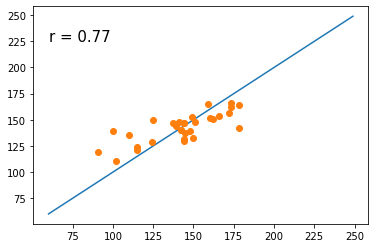

In [35]:
from matplotlib import pyplot as plt
from numpy import *
import scipy.stats as stats
print(json_load0['matrix']['capacity_0.86::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'])
observed = json_load0['matrix']['capacity_0.86::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8']
predicted = list(json_load['capacity_0.86::TrajectoryFastCharge'].values())
#print(json_load['capacity_0.86::TrajectoryFastCharge'].values())
#print(len(json_load0['matrix']['capacity_0.86::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8']))
x = range(60,250)
y = range(60,250)
plt.plot(x,y)
plt.text(60, 225, 'r = 0.77', size = '15')
#print(json_load0['matrix']['capacity_0.86::TrajectoryFastCharge::319cec55cc030c1911b2530cae3fc2df8d3c24912ae01ee4172ea4ca4caddec8'])
plt.plot(observed, predicted, 'o')
slope, intercept, r, p, std_err = stats.linregress(observed, predicted)
print(r)#  -1 1 best 0 bad 0.86 is good
print(p)
print(std_err)
plt.savefig("firstA43batterylife.pdf")

In [85]:
vi /usr/siqianli/lib/python3.8/site-packages/bee

SyntaxError: invalid syntax (2440154928.py, line 1)

In [86]:
pwd

'/Users/siqianli/Desktop'

In [103]:
Dir = '/Users/siqianli/Desktop/battery/jsonA43'

In [112]:
#files = os.listdir(Dir)
files = glob.glob(Dir +"/*")
print(type(files))


<class 'list'>


/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-73_0C_CH01.json
dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

...

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

dict_keys(['@module', '@class', 'raw_data', 'metadata', 'paths', 'barcode', 'protocol', 'channel_id', 'summary', 'cycles_interpolated', 'diagnostic_summary', 'diagnostic_interpolated', 'structuring_parameters', 'schema_path'])
dict_keys(['cycle_index', 'discharge_capacity', 'charge_capacity', 'discharge_energy', 'charge_energy', 'dc_internal_resistance', 'temperature_maximum', 'temperature_average', 'temperature_minimum', 'date_time_iso', 'energy_efficiency', 'charge_throughput', 'energy_throughput', 'charge_duration', 'time_temperature_integrated', 'paused', 'CV_time', 'CV_current', 'CV_capacity'])
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 

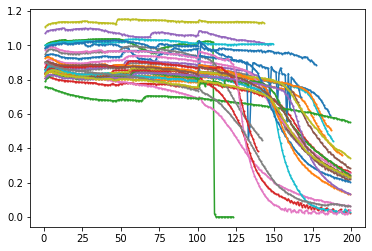

In [143]:
for file in files:
    print(file)
    json_open_data = open(file)
    json_load_data = json.load(json_open_data)
    print(json_load_data.keys())
    print(json_load_data['summary'].keys())
    #print(json_load_data['cycles_interpolated'].keys())
    #print(json_load_data['summary']['discharge_capacity'])
    #print(json_load_data['raw_data'].keys())
    xc=json_load_data['cycles_interpolated']['discharge_capacity']
    #print(xc[:1000])
    yc=json_load_data['cycles_interpolated']['voltage']
    #print(yc[:1000])
    zc=json_load_data['cycles_interpolated']['cycle_index']
    xr=json_load_data['raw_data']['discharge_capacity']
    #print(xr)
    yr=json_load_data['raw_data']['voltage']
    zr=json_load_data['raw_data']['cycle_index']
    xs=json_load_data['summary']['discharge_capacity']
    ys=json_load_data['summary']['discharge_capacity']
    ys=[1.75]*len(json_load_data['summary']['discharge_capacity'])
    zs=json_load_data['summary']['cycle_index']
    #print(type(xs))
    #print(zs)
    print(zs)
    print(xs)
    print(len(zs))
    print(len(xs))
    #print(type(zs))
    #zs100 = zs[:100]
    #xs100 = xs[:100]
    #print(zs100)
    #print(xs100)
    
    #print(len(xs))
    #print(len(yr))
    #plt.xlim(0,200)
    #plt.ylim(0, 1.2)
    plt.plot(zs,xs, marker = 'o', markersize = 1) # 绘制summary discharge capacity & cycle index
    x2 = []
    y2 = []
    for i in [s for s in range(0,len(xr)-1) if zr[s]==10]:
    #print(xr[i])
        x2.append(xr[i])
        #print(x2)
        y2.append(yr[i])
        #print(y2)
        #print(len(y2))
        #plt.xlim(0,1.2)
        #plt.ylim(1.6, 3.3)
        
       # plt.plot(x2,y2, color = 'g' )
    #print(len(x2))
    #print(x2)
    x100 = []
    y100 = []
    for i in [s for s in range(0,len(xr)-1) if zr[s]==100]:
    #print(xr[i])
        x100.append(xr[i])
        #print(x100)
        y100.append(yr[i])
        #print(y100)
        #plt.plot(x100,y100, color = 'y')
        #plt.plot(xr,yr,'.')
   # print(len(x100))
    #print(x100)
        
    x20c = []
    y20c = []
    for i in [s for s in range(0,len(xc)-1) if zc[s]==10]:
    #print(xd[i])
        x20c.append(xc[i])
        y20c.append(yc[i])
        #plt.plot(x20c,y20c,'.', color = 'r')
    x100c = []
    y100c = []
    for i in [s for s in range(0,len(xc)-1) if zc[s]==100]:
    #print(xd[i])
        x100c.append(xc[i])
        y100c.append(yc[i])
        #plt.plot(x100c,y100c,'.', color = 'b')

        
        
        
        
        
        

In [185]:
var = []
lenzs = []
for file in files:
    print(file)
    
    json_open_data = open(file)
    #json_open_data = open('./battery/jsonA43/2022-10-27_43A-71_0C_CH01.json', 'r')
    #json_open = open('./PredictedDegradationDF-2022-03-10_18.16.59.650398.json', 'r')
    json_load_data = json.load(json_open_data)

    print(json_load_data.keys())
    #print(json_load_data['summary'].keys())
    #print(json_load_data['structuring_parameters'].keys())
    #print(json_load_data['summary']['discharge_capacity'])
    print(json_load_data['cycles_interpolated'].keys())
    #print(json_load_data['raw_data'].keys())
    #print(json_load_data['summary'].keys())
    #print(json_load_data['raw_data']['discharge_capacity'])
    xi=json_load_data['cycles_interpolated']['discharge_capacity']
    yi=json_load_data['cycles_interpolated']['voltage']
    zi=json_load_data['cycles_interpolated']['cycle_index']
    xd=json_load_data['raw_data']['discharge_capacity']
    yd=json_load_data['raw_data']['voltage']
    zd=json_load_data['raw_data']['cycle_index']
    xs=json_load_data['summary']['discharge_capacity']
    ys=json_load_data['summary']['discharge_capacity']
    #print(len(json_load_data['summary']['discharge_capacity']))
    
    ys=[1.75]*len(json_load_data['summary']['discharge_capacity'])
    zs=json_load_data['summary']['cycle_index']
    print(zd)
    
    # 绘制figure 2a
    xs = []
    ys = []

    for i in [s for s in range(0,len(xd)-1) if zd[s]==10]:
        #print(xd[i])
        xs.append(xd[i])
        ys.append(yd[i])
    #print(xs)
        #print(ys)
        #print(len(xs))
        #plt.plot(xs,ys,  color ='b')
    xs = []
    ys = []
    for i in [s for s in range(0,len(xd)-1) if zd[s]==100]:
        #print(xd[i])
        xs.append(xd[i])

        ys.append(yd[i])
        #print(xs)
        #print(ys)
        #print(len(xs))
        #plt.plot(xs,ys,  color = 'y')
        
    xi10 = []
    yi10 = []
# 绘制discharge difference
    for i in [s for s in range(0,len(xi)-1) if zi[s]==10]:
        #print(xd[i])
        xi10.append(xi[i])
        yi10.append(yi[i])
        #plt.plot(xi10,yi10, marker = '.', color = 'g')
    #print("number: %s" % len(xi10))
    #print("ci10")
    #print(xi10)
    #print(len(yi10))
    #print(yi10)

    xi100 = []
    yi100 = []
    for i in [s for s in range(0,len(xi)-1) if zi[s]==100]:
        #print(xd[i])
        xi100.append(xi[i])
        yi100.append(yi[i])
        #plt.plot(xi100,yi100, marker = '.', color = 'r')
    #print("ci100")
    #print(xi100)
    
   # print(len(xi100))
    #print(yi100)
    #print(len(yi100))
    #plt.plot(xi100,yi100, marker = 'o')

    xi10arr = np.array(xi10)
    #print(type(xi10arr))
    xi100arr = np.array(xi100)
    #print(type(xi100arr))

    xdiffarr = xi100arr - xi10arr
    xdiff = np.nan_to_num(xdiffarr)
    print(xdiff)
    print("*" * 50)
    xdifflist = xdiffarr.tolist()
    #print(xdifflist)
    
    #print(xdiffarr)
    print(np.var(xdiff))
    xva = np.var(xdiff)
    xvl = xva.tolist()
    print(type(xvl))
    var.append(xvl)
    print(var)
    
    lenzs.append(len(zs))
    print(lenzs)
    
    #plt.plot(xdifflist, yi10)
    #plt.plot(xvl, lenzs)
    
    
# plot variance and cycle index
#plt.scatter(var, lenzs)
        
    
        
    
#print(xi)
#print(len(xi))
#print(type(xi))
#print(xi[1000:2000])
#print(yi)
#print(xi[0:2000])
#print(zi)
#print(xd)
#print(len(ys))
#print(zs)
#print(len(zs))
#plt.plot(zs,xs, marker ='.')

/Users/siqianli/Desktop/221206_rawdata/A43/43A-96_101cyc.csv


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x91 in position 0: invalid start byte

/Users/siqianli/Desktop/battery/jsonA43/2022-10-27_43A-36_0C_CH01.json
44
44
43
43
number: 1000
[0.43865013122558594, 0.4371069371700287, 0.43556374311447144, 0.4340205490589142, 0.43247735500335693, 0.4309918284416199, 0.42953237891197205, 0.42807289958000183, 0.4266134202480316, 0.4251539707183838, 0.4236944913864136, 0.42223501205444336, 0.42077556252479553, 0.4193160831928253, 0.4178566038608551, 0.4163971543312073, 0.41493767499923706, 0.41347819566726685, 0.412018746137619, 0.4105592668056488, 0.409099817276001, 0.4076556861400604, 0.4062589108943939, 0.4048621654510498, 0.4034654200077057, 0.4020686447620392, 0.40067189931869507, 0.39927512407302856, 0.39787837862968445, 0.39648160338401794, 0.39508485794067383, 0.3936880826950073, 0.3922913372516632, 0.3908945918083191, 0.3894978165626526, 0.38810107111930847, 0.38670429587364197, 0.38530755043029785, 0.38391414284706116, 0.38257139921188354, 0.38122862577438354, 0.37988588213920593, 0.3785431385040283, 0.3772003948688507, 0.37

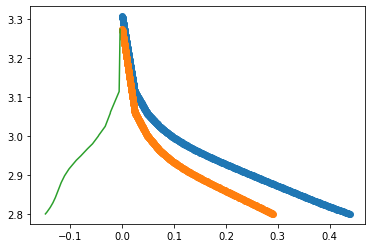

In [13]:
print(file)
xs = []
ys = []

for i in [s for s in range(0,len(xd)-1) if zd[s]==10]:
    #print(xd[i])
    xs.append(xd[i])
    ys.append(yd[i])
print(len(xs))
print(len(ys))
    #print(len(xs))

#plt.plot(xs,ys,  color ='g')


   
xs = []
ys = []
for i in [s for s in range(0,len(xd)-1) if zd[s]==100]:
    #print(xd[i])
    xs.append(xd[i])

    ys.append(yd[i])
print(len(xs))
print(len(ys))
#print(len(xs))
#plt.plot(xs,ys,  color = 'r')

xi10 = []
yi10 = []

for i in [s for s in range(0,len(xi)-1) if zi[s]==10]:
    #print(xd[i])
    xi10.append(xi[i])
    yi10.append(yi[i])
plt.plot(xi10,yi10, marker = 'o')
print("number: %s" % len(xi10))
print(xi10)
print(len(yi10))
print(yi10)

xi100 = []
yi100 = []
for i in [s for s in range(0,len(xi)-1) if zi[s]==100]:
    #print(xd[i])
    xi100.append(xi[i])
    yi100.append(yi[i])
print(xi100)
print(len(xi100))
print(yi100)
print(len(yi100))
plt.plot(xi100,yi100, marker = 'o')

xi10arr = np.array(xi10)
print(type(xi10arr))
xi100arr = np.array(xi100)
print(type(xi100arr))

xdiffarr = xi100arr - xi10arr

xdifflist = xdiffarr.tolist()
print(len(xdifflist))
plt.plot(xdifflist, yi10)


3
34
34
[0.0, 1.9999999999881224e-08, 1.9999999996411777e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.9999999978945766e-08, 0.0, 4.000000003445692e-08, 0.0, 0.0, 0.0, 8.000000001340268e-08, 0.0, 0.0, 0.0, 7.999999995789153e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.000227959999999916]


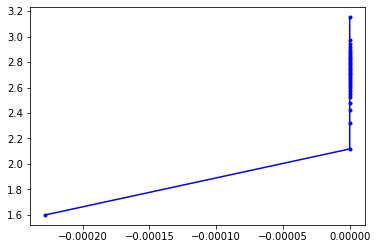

In [475]:
'''totally wrong and meaningless

b = len(x10) - len(x100)
print(b)
print(len(x10)-b)
x10_new = x10[:(len(x10)-b)]
x100_array = np.array(x100)
x10_array = np.array(x100_new)
print(len(y100))
dif_array = np.array(x100) - np.array(x10_new)
dif_array
dif_list = dif_array.tolist()
print(dif_list)
#Dif100_2.append(dif_list)
#print(Dif100_2)
plt.plot(dif_list, y100, color = 'b', marker = 'o', markersize = 3)
'''

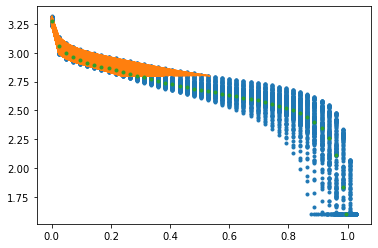

In [64]:
from matplotlib import pyplot as plt

plt.plot(xd,yd,'.')
plt.plot(xi,yi)
plt.plot(xs,ys,'.')

In [17]:
a = [1,2,3,4,5]
b = [5,4,3,2,1]
c = [a[i] - b[i] for i in range(0, len(a))]
print(c)

[-4, -2, 0, 2, 4]


In [87]:
!beep featurize -h  $stringj

2022-12-05 15:41:40 INFO     Featurizing 0 files
Traceback (most recent call last):
  File "/Users/siqianli/opt/anaconda3/bin/beep", line 8, in <module>
    sys.exit(cli())
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1128, in __call__
    return self.main(*args, **kwargs)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1053, in main
    rv = self.invoke(ctx)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1659, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 1395, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/core.py", line 754, in invoke
    return __callback(*args, **kwargs)
  File "/Users/siqianli/opt/anaconda3/lib/python3.9/site-packages/click/decorators.py", line 26, in

In [88]:
{
  "HPPCResistanceVoltageFeatures":
      {
        "diag_pos": 1,
        "soc_window": 8,
      }
}

{'HPPCResistanceVoltageFeatures': {'diag_pos': 1, 'soc_window': 8}}

In [98]:
!beep featurize -h '{"HPPCResistanceVoltageFeatures":{"diag_pos": 1, "soc_window": 8}}' $stringj

2022-12-05 15:51:26 INFO     Featurizing 0 files
2022-12-05 15:51:26 INFO     Applying 5 featurizers to each of 0 files
CRITICAL:root:Feature matrix could not be created: 'TypeError'!
2022-12-05 15:51:26 INFO     Featurization report:
2022-12-05 15:51:26 INFO     	All 5 featurizers succeeded: 0/0
2022-12-05 15:51:26 INFO     	Some featurizers succeeded: 0/0
2022-12-05 15:51:26 INFO     	No featurizers succeeded or file failed: 0/0
2022-12-05 15:51:26 INFO     	Featurization matrix created: False
